In [112]:
import sys
print(sys.path)

['/usr/lib/python314.zip', '/usr/lib/python3.14', '/usr/lib/python3.14/lib-dynload', '', '/home/swaraj/python/Plasma/ss/lib/python3.14/site-packages', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT', '/home/swaraj/Git/Plasma/DTT']


In [113]:
import os
sys.path.append(os.path.abspath(".."))

In [114]:
import importlib
from DTTN_resources import psiBfield

importlib.reload(psiBfield)

g = psiBfield.extract_g()
psi_norm, BR, Bphi, BZ = psiBfield.compute_B(g)

g_file keywords extracted
Psi Normalized and Magnetic field BR Bphi BZ computed.


In [115]:
import matplotlib.pyplot as plt
import numpy as np

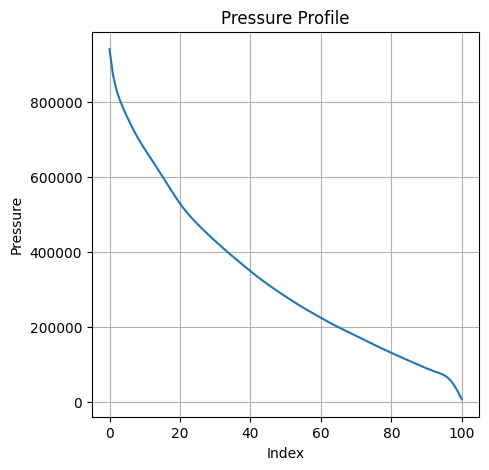

In [116]:
plt.figure(figsize=(5, 5))
plt.plot(g.pres)
plt.xlabel('Index')
plt.ylabel('Pressure')
plt.title('Pressure Profile')
plt.grid()
plt.show()

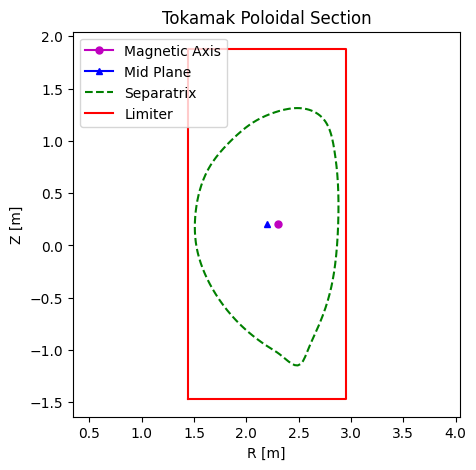

In [117]:
plt.figure(figsize=(5,5))
plt.plot(g.rmaxis, g.zmaxis, 'm', marker = 'o', markersize = 5, label = "Magnetic Axis")
plt.plot(g.rcentr, g.zmid, 'b',marker = '^', markersize = 5, label = "Mid Plane")
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.plot(g.rlim, g.zlim, 'r', label = "Limiter")
plt.title("Tokamak Poloidal Section")
plt.xlim(g.r_grid[:,0][0], g.r_grid[:,0][-1])
plt.ylim(g.z_grid[0,:][0], g.z_grid[0,:][-1])
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend()
plt.show()

/tmp/ipykernel_122620/1801196969.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


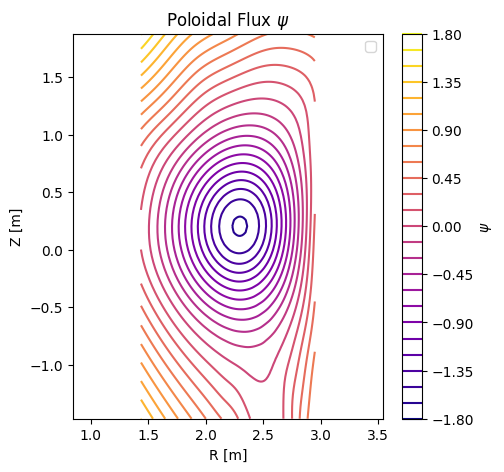

In [118]:
plt.figure(figsize = (5,5))

plt.contour(g.r_grid, g.z_grid, g.psi, levels = 30, cmap = 'plasma')
plt.colorbar(label = r'$\psi$')
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.title(r"Poloidal Flux $\psi$")
plt.axis('equal')
plt.legend()
plt.show()

/tmp/ipykernel_122620/1103649705.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


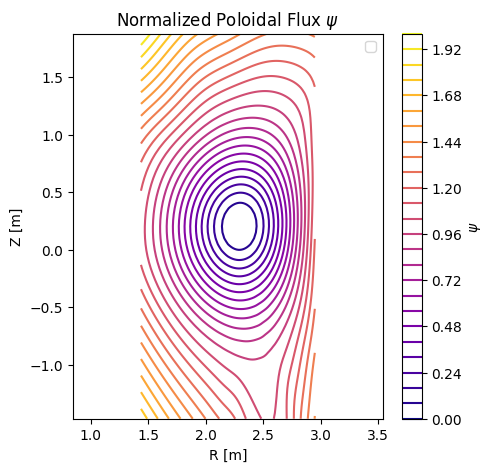

In [119]:
plt.figure(figsize = (5,5))

plt.contour(g.r_grid, g.z_grid, psi_norm, levels = 30, cmap = 'plasma')
plt.colorbar(label = r'$\psi$')
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.title(r"Normalized Poloidal Flux $\psi$")
plt.axis('equal')
plt.legend()
plt.show()

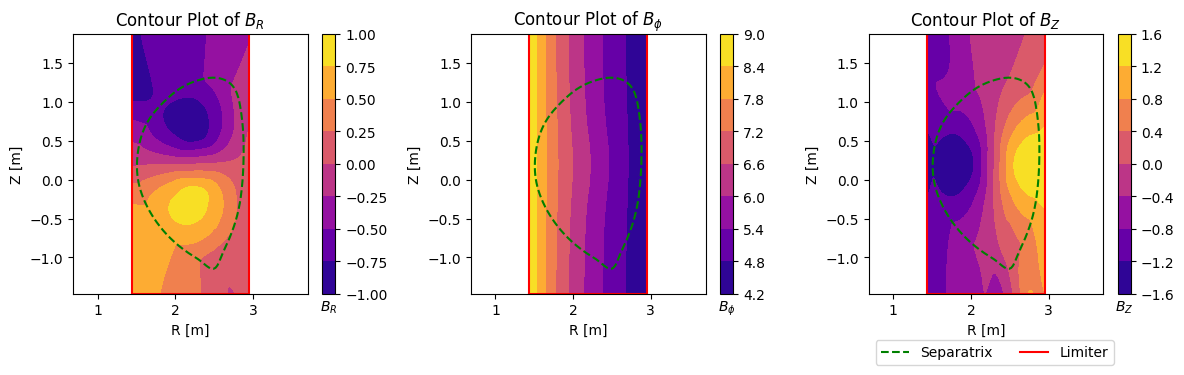

In [120]:
plt.figure(figsize = (12,4))

plt.subplot(1,3,1)
plt.contourf(g.r_grid, g.z_grid, BR, cmap = 'plasma')
cbar = plt.colorbar()
cbar.ax.set_xlabel(r'$B_R$')
cbar.ax.xaxis.set_label_position('bottom')
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, 'r', label = 'Limiter')
plt.title(r'Contour Plot of $B_R$')

plt.subplot(1,3,2)
plt.contourf(g.r_grid, g.z_grid, Bphi, cmap = 'plasma')
cbar = plt.colorbar()
cbar.ax.set_xlabel(r'$B_\phi$')
cbar.ax.xaxis.set_label_position('bottom')
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, 'r', label = 'Limiter')
plt.title(r'Contour Plot of $B_{\phi}$')

plt.subplot(1,3,3)
plt.contourf(g.r_grid, g.z_grid, BZ, cmap = 'plasma')
cbar = plt.colorbar()
cbar.ax.set_xlabel(r'$B_Z$')
cbar.ax.xaxis.set_label_position('bottom')
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.axis('equal')
plt.plot(g.rbdry, g.zbdry, 'g--', label = 'Separatrix')
plt.plot(g.rlim, g.zlim, 'r', label = 'Limiter')
plt.legend(loc='lower left', ncols=2, bbox_to_anchor=(0,-0.3))
plt.title(r'Contour Plot of $B_Z$')


plt.tight_layout()
plt.show()


In [121]:
rtraj, ztraj = psiBfield.field_tracing(g, psi_norm, BR, BZ)

Poloidal field line trajectories computed.


In [122]:
cumulative_distances = []
for i in range(len(rtraj)):
    dr = np.diff(rtraj[i])
    dz = np.diff(ztraj[i])
    distances = np.sqrt(dr**2 + dz**2)
    cumulative_distance = np.cumsum(distances)
    cumulative_distance = np.insert(cumulative_distance, 0, 0)
    cumulative_distances.append([cumulative_distance])


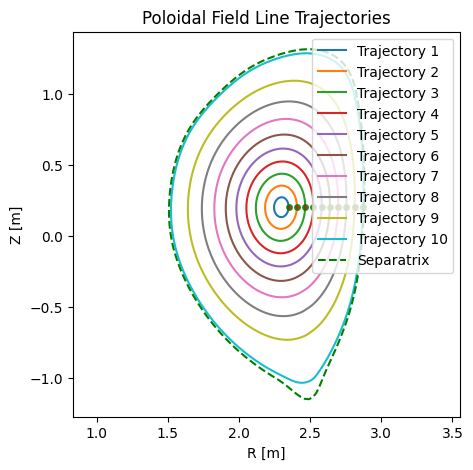

In [123]:
plt.figure(figsize=(5, 5))
for i in range(len(rtraj)):
    plt.plot(rtraj[i], ztraj[i], label = f"Trajectory {i+1}")
    plt.plot(rtraj[i][0], ztraj[i][0], 'go', markersize=4, alpha=0.8)
    plt.plot(rtraj[i][-1], ztraj[i][-1], 'ro', markersize=2, alpha=0.4)
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Poloidal Field Line Trajectories")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [124]:
r_grid_points, z_grid_points = psiBfield.grid_points(rtraj, ztraj)

Cumulative distances along trajectories computed.
Grid points along trajectories computed.


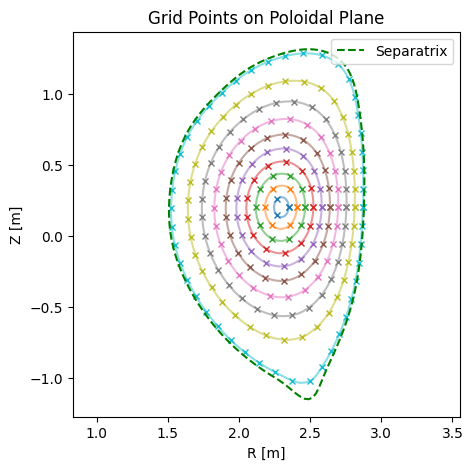

In [125]:
plt.figure(figsize=(5, 5))
for i in range(len(r_grid_points)):
    point_plot = plt.plot(r_grid_points[i], z_grid_points[i], 'x', markersize=5)
    color_i = point_plot[0].get_color()
    plt.plot(rtraj[i], ztraj[i], alpha = 0.5, color=color_i)
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Grid Points on Poloidal Plane")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [126]:
r_array = np.concatenate(r_grid_points)
z_array = np.concatenate(z_grid_points)

points = np.column_stack((r_array, z_array))

from scipy.spatial import Delaunay

tri = Delaunay(points)

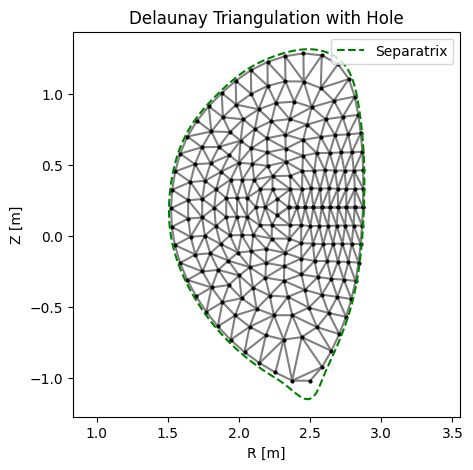

In [129]:
plt.figure(figsize=(5,5))
plt.triplot(points[:,0], points[:,1], tri.simplices, color='gray', markersize=2)
plt.plot(points[:,0], points[:,1], 'ko', markersize=2)
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Delaunay Triangulation with Hole")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [127]:
hole_radius = 0.12

filtered_triangles_with_hole = []

for tri_indices in tri.simplices:
    p1, p2, p3 = points[tri_indices]

    centroid_r, centroid_z = (p1 + p2 + p3) / 3

    distance = np.sqrt((centroid_r - g.rmaxis)**2 + (centroid_z - g.zmaxis)**2)

    if distance > hole_radius:
        # print(f"Triangle with vertices {p1}, {p2}, {p3} is too close to the magnetic axis and will be removed.")
        filtered_triangles_with_hole.append(tri_indices)

filtered_triangles_with_hole = np.array(filtered_triangles_with_hole)

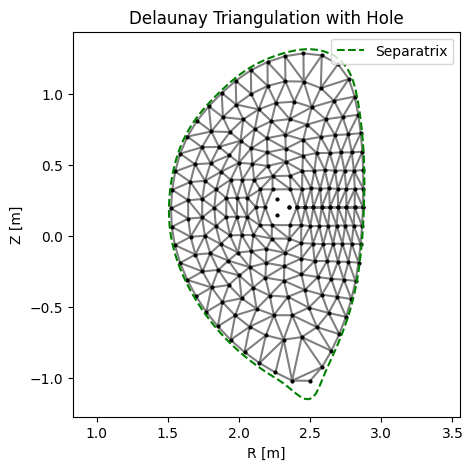

In [128]:
plt.figure(figsize=(5,5))
plt.triplot(points[:,0], points[:,1], filtered_triangles_with_hole, color='gray', markersize=2)
plt.plot(points[:,0], points[:,1], 'ko', markersize=2)
plt.plot(g.rbdry, g.zbdry, 'g--', label = "Separatrix")
plt.title("Delaunay Triangulation with Hole")
plt.xlabel("R [m]")
plt.ylabel("Z [m]")
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()